Para Verificar Performance da GPU Usar o Comando:

watch -n 1 amd-smi

## Modo do Script:

TRAIN: o modelo será treinado e o melhor registrado será salvo.

TEST: o modelo salvo será testado com o dataset de teste

BOTH: o modelo sera treinado, salvo e testado

# Setup do Projeto

In [1]:
import torch
from config import *

# Setup Agnostic Code for GPU/CPU
if torch.cuda.is_available():
    device = 'cuda'
    print(f"CUDA está disponivel!\nDispositivo configurado para: {device}\nDevice count: {torch.cuda.device_count()}\nNome do dispositivo: {torch.cuda.get_device_name(0)}\nVersao do PyTorch: {torch.__version__}")
else:
    device = 'cpu'
    print(f"CUDA não está disponível.\nDispositivo configurado para: {device}\nVersao do PyTorch: {torch.__version__}")

CUDA está disponivel!
Dispositivo configurado para: cuda
Device count: 1
Nome do dispositivo: AMD Radeon RX 7800 XT
Versao do PyTorch: 2.8.0+rocm7.2.0.gitbf943426


In [2]:
# Bibliotecas e imports
import custom_cityscapes as ccs
import custom_transforms as ctr
import custom_metrics as cmt
import models.FastSCNN as fscnn
import train_model as tr
from utils import *

from torchvision import datasets
from torch.utils.data import DataLoader
from torchinfo import summary
from torch import optim
from kornia import losses
# Mais informacoes em https://lightning.ai/docs/torchmetrics/stable/classification/jaccard_index.html#torchmetrics.classification.MulticlassJaccardIndex
from torchmetrics.classification import MulticlassJaccardIndex # Jaccard Index eh a mesma coisa que IoU (Intersection over Union) e esse opjeto pode calcular tambem iIoU
from pathlib import Path
import json

/home/jose-vitor/Documents/pytorch_projects/Fast-SCNN/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preparando o Dataset Cityscapes

In [3]:
ds_lables = ccs.CityscapesLables()

# Criando o colormap para as classes
cmap = ds_lables.get_cmap()

# Imprimindo informacoes relevantes
print(f"O dataset possui {len(ds_lables.id_names)} classes treinaveis:")
ds_lables.id_names

O dataset possui 20 classes treinaveis:


{0: 'road',
 1: 'sidewalk',
 2: 'building',
 3: 'wall',
 4: 'fence',
 5: 'pole',
 6: 'traffic light',
 7: 'traffic sign',
 8: 'vegetation',
 9: 'terrain',
 10: 'sky',
 11: 'person',
 12: 'rider',
 13: 'car',
 14: 'truck',
 15: 'bus',
 16: 'train',
 17: 'motorcycle',
 18: 'bicycle',
 255: 'ignore'}

# Importar o Dataset Cityscapes

Definir Funções de Transform

In [4]:
custom_trans = ctr.Transforms(conv_size=(IM_HEIGHT, IM_WIDTH),
                              lable_conversion=ds_lables.lable_conversion)

Importar Dataset

In [5]:
train_dataset = ccs.AugmentedCityscapes(DATA_PATH,
                             split = 'train',
                             mode='fine',
                             target_type='semantic',
                             transform=custom_trans.train_transform,
                             target_transform=custom_trans.target_transform,
                             data_augmentation=custom_trans.data_augmentation,
                             post_data_augmentation=custom_trans.post_data_augmentation)
val_dataset = datasets.Cityscapes(DATA_PATH,
                           split = 'val',
                           mode='fine',
                           target_type='semantic',
                           transform=custom_trans.val_transform,
                           target_transform=custom_trans.target_transform)
test_dataset = datasets.Cityscapes(DATA_PATH,
                            split = 'test',
                            mode='fine',
                            target_type='semantic',
                            transform=custom_trans.val_transform)

In [6]:
# Imprimir informacoes importantes dos datasets
img, smnt = train_dataset[0]
print(f"O Dataset de treino possui {len(train_dataset)} amostras.\n"
      f"O Dataset de validação possui {len(val_dataset)} amostras.\n"
      f"O Dataset de teste possui {len(test_dataset)} amostras.\n"
      f"Cada imagem posssui tamanho {img.shape} e tipo {img.dtype}, e cada mascara possui tamanho {smnt.shape} e tipo {smnt.dtype}.\n")

#print(f"Primeira Imagem do dataset de treino:\n{img}\nPrimenra mascara do dataset de treino:\n{smnt}")

O Dataset de treino possui 2975 amostras.
O Dataset de validação possui 500 amostras.
O Dataset de teste possui 1525 amostras.
Cada imagem posssui tamanho torch.Size([3, 768, 768]) e tipo torch.float32, e cada mascara possui tamanho torch.Size([768, 768]) e tipo torch.uint8.



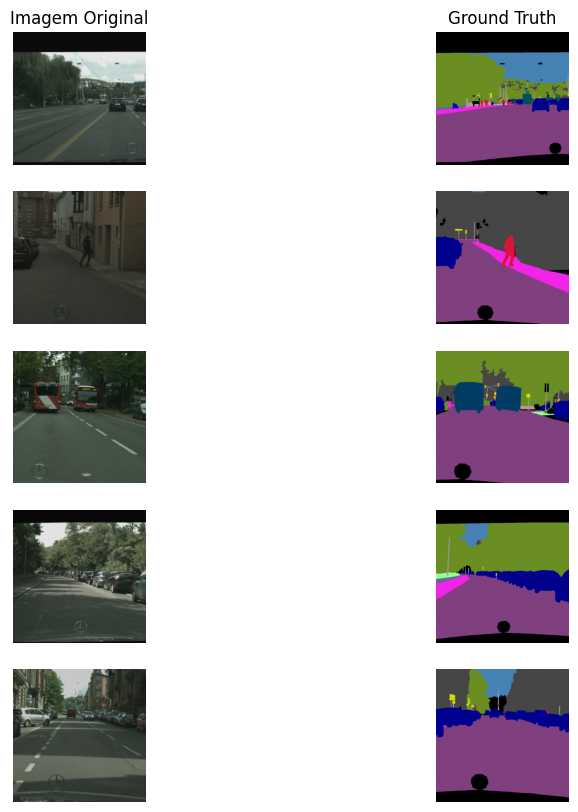

In [6]:
# Testando a funcao de exibicao
dataset_show(train_dataset, n=5, cmap=cmap)

In [7]:
# Gerar lista com pesos para as classes a partir do histograma de frequencia das classes no dataset

# Define e cria pasta para salvar pesos e histogramas
save_path = "./classes_weights"

# Metodo para calcular os pesos das classes, pode ser 'enet', 'median_freq_balancing' ou 'logarithmic'
method = 'enet'

# Define o caminho do arquivo onde os pesos das classes serao salvos, e cria a pasta caso ela nao exista
save_path = Path(save_path / Path(f'class_weights_{method}.json'))

if GENERATE_HISTOGRAM:

    # Criar um dataset sem data augmentation para calcular o histograma de frequencia das classes no dataset, e consequentemente os pesos das classes
    histogram_dataset = datasets.Cityscapes(DATA_PATH,
                                            split = 'train',
                                            mode='fine',
                                            target_type='semantic',
                                            transform=custom_trans.val_transform,
                                            target_transform=custom_trans.target_transform)
    
    # Criar um dataloader para o dataset de histograma, sem shuffle, para calcular o histograma de frequencia das classes no dataset
    histogram_dataloader = DataLoader(histogram_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)
    
    # Chama a funcao para calcular os pesos e o histograma, e os salva na pasta definida
    class_weights = ds_lables.get_weights(histogram_dataloader, method=method, print_histogram=True, save_path=save_path, device=device)

    print(f"Pesos das classes calculados e salvos no arquivo {save_path}:\n{class_weights}")

else:
    # pega os pesos das classes calculados anteriormente
    with open(save_path, "r") as f:
        class_weights = torch.tensor(list(json.load(f).values())).to(device) # Carrega os pesos das classes do arquivo salvo anteriormente e converte para tensor
        print(f"Pesos das classes carregados do arquivo {save_path}:\n{class_weights}")

Pesos das classes carregados do arquivo classes_weights/class_weights_enet.json:
tensor([ 3.3632, 14.0408,  4.9860, 39.2617, 36.5217, 32.8974, 46.2848, 40.6889,
         6.6957, 33.5658, 18.4602, 32.9789, 47.6775, 12.7070, 45.2076, 45.7850,
        45.8268, 48.4075, 42.7600], device='cuda:0')


Criar dataloaders

In [8]:
# Criando datalaoders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)

In [10]:
# Imprimindo informacoes relevantes dos dataloaders
train_features_batch, train_labels_batch = next(iter(train_dataloader))
val_features_batch, val_labels_batch = next(iter(val_dataloader))
print(f"O pacote de imagens para treino possui tamanho: {train_features_batch.size()}, e o tamanho do pacote da mascaras para treino possui tamanho: {train_labels_batch.size()}")
print(f"O pacote de imagens para validacao possui tamanho: {val_features_batch.size()}, e o tamanho do pacote da mascaras para validacao possui tamanho: {val_labels_batch.size()}")

O pacote de imagens para treino possui tamanho: torch.Size([12, 3, 768, 768]), e o tamanho do pacote da mascaras para treino possui tamanho: torch.Size([12, 768, 768])
O pacote de imagens para validacao possui tamanho: torch.Size([12, 3, 1024, 2048]), e o tamanho do pacote da mascaras para validacao possui tamanho: torch.Size([12, 1024, 2048])


## Criar Modelo 

In [9]:
# CRIANDO O MODELO
model = fscnn.FastSCNN(num_classes=NUM_CLASSES, aux=False).to(device)
model = load_state_dict(model, path="./model_weights/og_params/fast_scnn_citys.pth")


# Evita erro de memória no torchinfo com resolução alta
model.eval()
summary(model,
        input_size=(1, 3, IM_HEIGHT, IM_WIDTH),
        device=device,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]) # especificando para mostrar os nomes das variaveis, o que ajuda a entender melhor a arquitetura do modelo e a quantidade de parametros treinaveis em cada camada.

Carregando modelo fast_scnn_citys


Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
FastSCNN (FastSCNN)                                     [1, 3, 1024, 2048]   [1, 19, 1024, 2048]  --                   True
├─LearningToDownsample (learning_to_downsample)         [1, 3, 1024, 2048]   [1, 64, 128, 256]    --                   True
│    └─_ConvBNReLU (conv)                               [1, 3, 1024, 2048]   [1, 32, 511, 1023]   --                   True
│    │    └─Sequential (conv)                           [1, 3, 1024, 2048]   [1, 32, 511, 1023]   928                  True
│    └─_DSConv (dsconv1)                                [1, 32, 511, 1023]   [1, 48, 256, 512]    --                   True
│    │    └─Sequential (conv)                           [1, 32, 511, 1023]   [1, 48, 256, 512]    1,984                True
│    └─_DSConv (dsconv2)                                [1, 48, 256, 512]    [1, 64, 128, 256]    --                   True
│  

In [12]:
# Testar Modelo com uma imagem do dataset
test_input = train_dataset[0][0].unsqueeze(0).to(device) # Adiciona uma dimensão de batch e move para o dispositivo
test_output = model(test_input)
test_output_softmax = torch.softmax(test_output, dim=1).argmax(dim=1)
print(f"Tamanho da entrada: {test_input.shape}\n"
      f"Tamanho da saida: {test_output.shape}\n"
      f"Tamanho da saida com softmax: {test_output_softmax.shape}")
test_output_softmax

Tamanho da entrada: torch.Size([1, 3, 768, 768])
Tamanho da saida: torch.Size([1, 19, 768, 768])
Tamanho da saida com softmax: torch.Size([1, 768, 768])


tensor([[[ 2,  2,  2,  ...,  2,  2,  2],
         [ 2,  2,  2,  ...,  2,  2,  2],
         [ 2,  2,  2,  ...,  2,  2,  2],
         ...,
         [13, 13, 13,  ..., 13, 13, 13],
         [13, 13, 13,  ..., 13, 13, 13],
         [13, 13, 13,  ..., 13, 13, 13]]], device='cuda:0')

## Treinar Modelo E MOSTRAR RESULTADOS

In [10]:
# Definir loss, optim e metricas

# Separa em dois grupos de parametros para aplicar diferentes decaimentos de pesos (L2 regularization), conforme mencionado no artigo original do Fast-SCNN
depthwise_params = []
non_depthwise_params = []
for name, param in model.named_parameters():
    # procura por convolucoes depthwise, que possuem kernel com 1 canal de entrada. Ex: [32, 1, 3, 3] (32 kernels de dimencao 3x3, um para cada canal)
    if param.requires_grad:
        if len(param.shape) == 4 and param.shape[1] == 1:
            depthwise_params.append(param)
        else:
            non_depthwise_params.append(param)

focal_loss = losses.FocalLoss(alpha=0.25, gamma=1.0, reduction='mean', weight=class_weights, ignore_index=255).to(device) # Focal Loss com pesos para lidar melhor com o desbalanceamento de classes
focal_tvensky_loss = cmt.FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=1.33, eps=1e-8, ignore_index=255).to(device) # Perda baseada em regiao, baseado em IoU, no entando com pesos para falsos positivos e falsos negativos, alem de correcao focal.
loss_fn = lambda outputs, targets: focal_loss(outputs, targets) + focal_tvensky_loss(outputs, targets) # Combinacao das duas loss functions para aproveitar os beneficios de ambas

optim_fn = optim.AdamW([
    {'params': depthwise_params, 'weight_decay': 0.0},
    {'params': non_depthwise_params, 'weight_decay': 4e-5}
], lr=LEARNING_RATE) # Otimizador com grupos de parametros para aplicar taxas de aprendizado diferentes no encoder e decoder

IoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=255, average='none').to(device)
mIoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=255, average='macro').to(device)
metrics = {'IoU': IoU_metric, 'mIoU': mIoU_metric} # Dicionário de metricas para facilitar o monitoramento durante o treinamento e validacao

# Escolha da metrica que sera avaliada para salvar o melhor modelo, pode ser 'loss' ou o nome de alguma metrica definida no dicionario de metricas, como 'IoU' ou 'mIoU'
val_to_monitor = 'mIoU'

In [11]:
# 1. Abre o arquivo original baixado
caminho_pesos = "./model_weights/og_params/fast_scnn_citys.pth"
pesos_baixados = torch.load(caminho_pesos, map_location='cpu')

# 2. Pega os nomes das primeiras camadas
chaves_baixadas = list(pesos_baixados.keys())
chaves_meu_modelo = list(model.state_dict().keys())

print("--- DIAGNÓSTICO DE PESOS ---")
print(f"O arquivo baixado tem a palavra 'module.'? {'Sim' if 'module.' in chaves_baixadas[0] else 'Não'}")
print(f"1ª chave do arquivo baixado: {chaves_baixadas[0]}")
print(f"1ª chave do seu modelo:      {chaves_meu_modelo[0]}")

# 3. Carregamento Cirúrgico Seguro (Ignorando a AuxLayer e o Module)
novo_state_dict = {}
for nome_baixado, pesos in pesos_baixados.items():
    # Remove o 'module.' se ele existir
    nome_corrigido = nome_baixado.replace('module.', '')
    
    # Só adiciona se a camada existir no SEU modelo atual (ignora a auxlayer)
    if nome_corrigido in chaves_meu_modelo:
        novo_state_dict[nome_corrigido] = pesos

# Carrega forçadamente e imprime o resultado
resultado = model.load_state_dict(novo_state_dict, strict=False)
print("\nResultado do carregamento seguro:")
print(f"Camadas ausentes no seu modelo (provavelmente a auxlayer): {len(resultado.unexpected_keys)}")

# --- A PROVA DOS 9: Teste a seco ---
print("Avaliando os pesos puros antes do treinamento...")
model.eval()
mIoU_metric.reset() # Garante que a métrica está zerada
with torch.no_grad():
    for X, y in val_dataloader:
        X, y = X.to(device), y.to(device)
        preds = model(X)
        mIoU_metric.update(preds, y.long())

miou_puro = mIoU_metric.compute().item()
print(f"--> mIoU Real dos Pesos Carregados: {miou_puro:.4f} <--")
# -----------------------------------

--- DIAGNÓSTICO DE PESOS ---
O arquivo baixado tem a palavra 'module.'? Não
1ª chave do arquivo baixado: learning_to_downsample.conv.conv.0.weight
1ª chave do seu modelo:      learning_to_downsample.conv.conv.0.weight

Resultado do carregamento seguro:
Camadas ausentes no seu modelo (provavelmente a auxlayer): 0
Avaliando os pesos puros antes do treinamento...
--> mIoU Real dos Pesos Carregados: 0.1713 <--


In [ ]:
# Treinar o modelo
#%env TORCH_USE_HIP_DSA=1
if SCRIPT_MODE != "TEST":
    model = torch.compile(model) # Compila o modelo para melhorar a performance.
    fit_model = tr.TrainModel(model, loss_fn, optim_fn, metrics,
                                val_to_monitor=val_to_monitor,
                                scheduler_name="ReduceLROnPlateau", # Scheduler para reduzir a taxa de aprendizado quando a metrica monitorada parar de melhorar, o que ajuda a escapar de platos e melhorar a convergencia.
                                max_lr = 1e-3, # valido apenas para o OneCycleLR, e ignorado caso scheduler_fn seja diferente de "OneCycleLR"
                                epochs=EPOCHS,
                                device=device)
    
    fit_model(train_dataloader, val_dataloader)

Melhor valor da metrica monitorada (mIoU) registrado no modelo salvo: 0.3980

EPOCH 1/10


100%|██████████| 248/248 [02:29<00:00,  1.65it/s]


train_loss: 0.2960 | train_mIoU: 0.2304 | val_loss: 0.3061 | val_mIoU: 0.2505 | 

EPOCH 2/10


100%|██████████| 248/248 [02:23<00:00,  1.72it/s]


train_loss: 0.2346 | train_mIoU: 0.2670 | val_loss: 0.2665 | val_mIoU: 0.2768 | 

EPOCH 3/10


100%|██████████| 248/248 [02:23<00:00,  1.73it/s]


train_loss: 0.2174 | train_mIoU: 0.2826 | val_loss: 0.2739 | val_mIoU: 0.2712 | 

EPOCH 4/10


 99%|█████████▉| 245/248 [02:21<00:01,  1.91it/s]

## TESTAR MODELO SALVO

<Figure size 500x500 with 0 Axes>

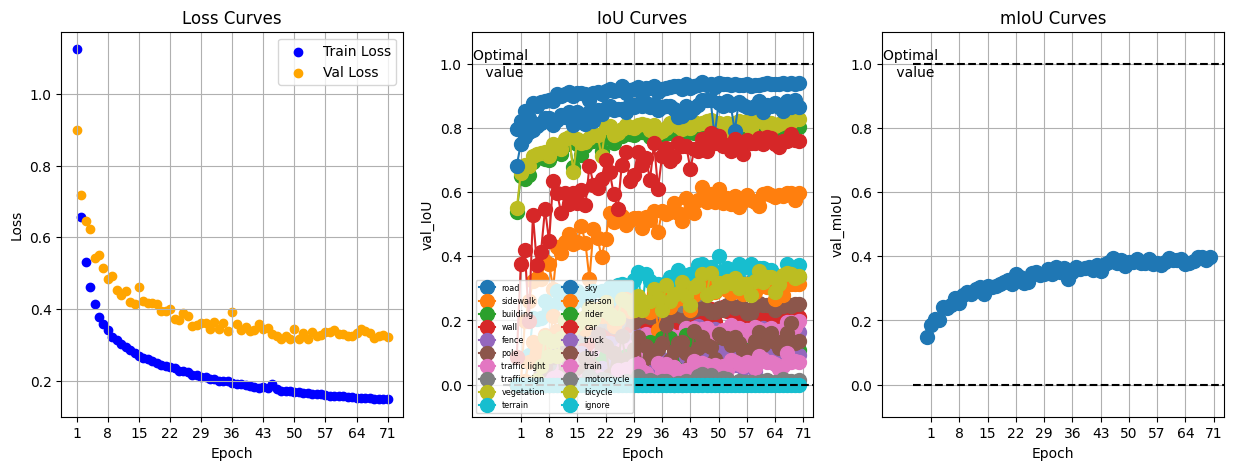

In [ ]:
if SCRIPT_MODE != "TRAIN":

    # Criando novo modelo para carregar o salvo
    loaded_model = fscnn.FastSCNN(num_classes=NUM_CLASSES, aux=True).to(device)

    # Carregando apenas os parametros (state_dict()), pois isso flexibiliza o modelo e evita erros de incompatibilidade com parametros e caminhos do modelo original
    # OBS: torch.load() carrega o modelo inteiro, nao apenas os parametros
    loaded_model, loaded_model_results = load_state_dict(loaded_model, name="best_model", load_reults=True, device=device)

    # Compila o modelo para melhorar a performance
    loaded_model = torch.compile(loaded_model)
    
    # Imprimir os resultados
    print_results(loaded_model_results, metrics)
    best_loaded_results = get_best_results(loaded_model_results, IoU_lables=ds_lables.id_names)

In [ ]:
best_loaded_results

{'val_loss': 0.3212999840577443,
 'val_IoU': {'road': 0.9396749138832092,
  'sidewalk': 0.5970247387886047,
  'building': 0.8029751777648926,
  'wall': 0.21069376170635223,
  'fence': 0.16255071759223938,
  'pole': 0.25133052468299866,
  'traffic light': 0.19741053879261017,
  'traffic sign': 0.33448103070259094,
  'vegetation': 0.8269854784011841,
  'terrain': 0.3724006712436676,
  'sky': 0.8650223016738892,
  'person': 0.31280532479286194,
  'rider': 0.10921436548233032,
  'car': 0.7598374485969543,
  'truck': 0.09357911348342896,
  'bus': 0.13727061450481415,
  'train': 0.07085682451725006,
  'motorcycle': 0.014799000695347786,
  'bicycle': 0.33944815397262573,
  'ignore': 0.0},
 'val_mIoU': 0.39795729517936707}

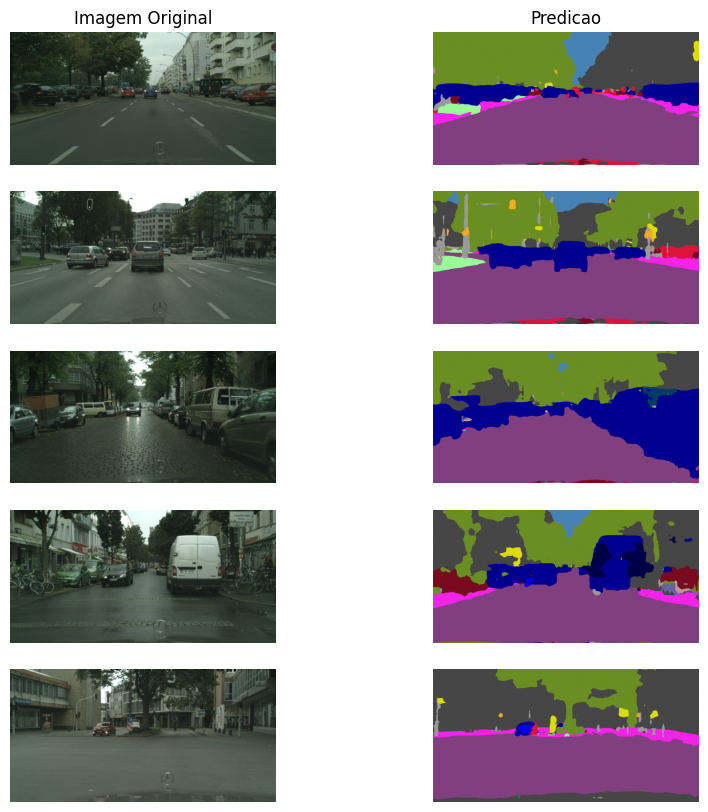

In [ ]:
# Teste do modelo
test_model(loaded_model, test_dataset, n=5, device=device, cmap=cmap)


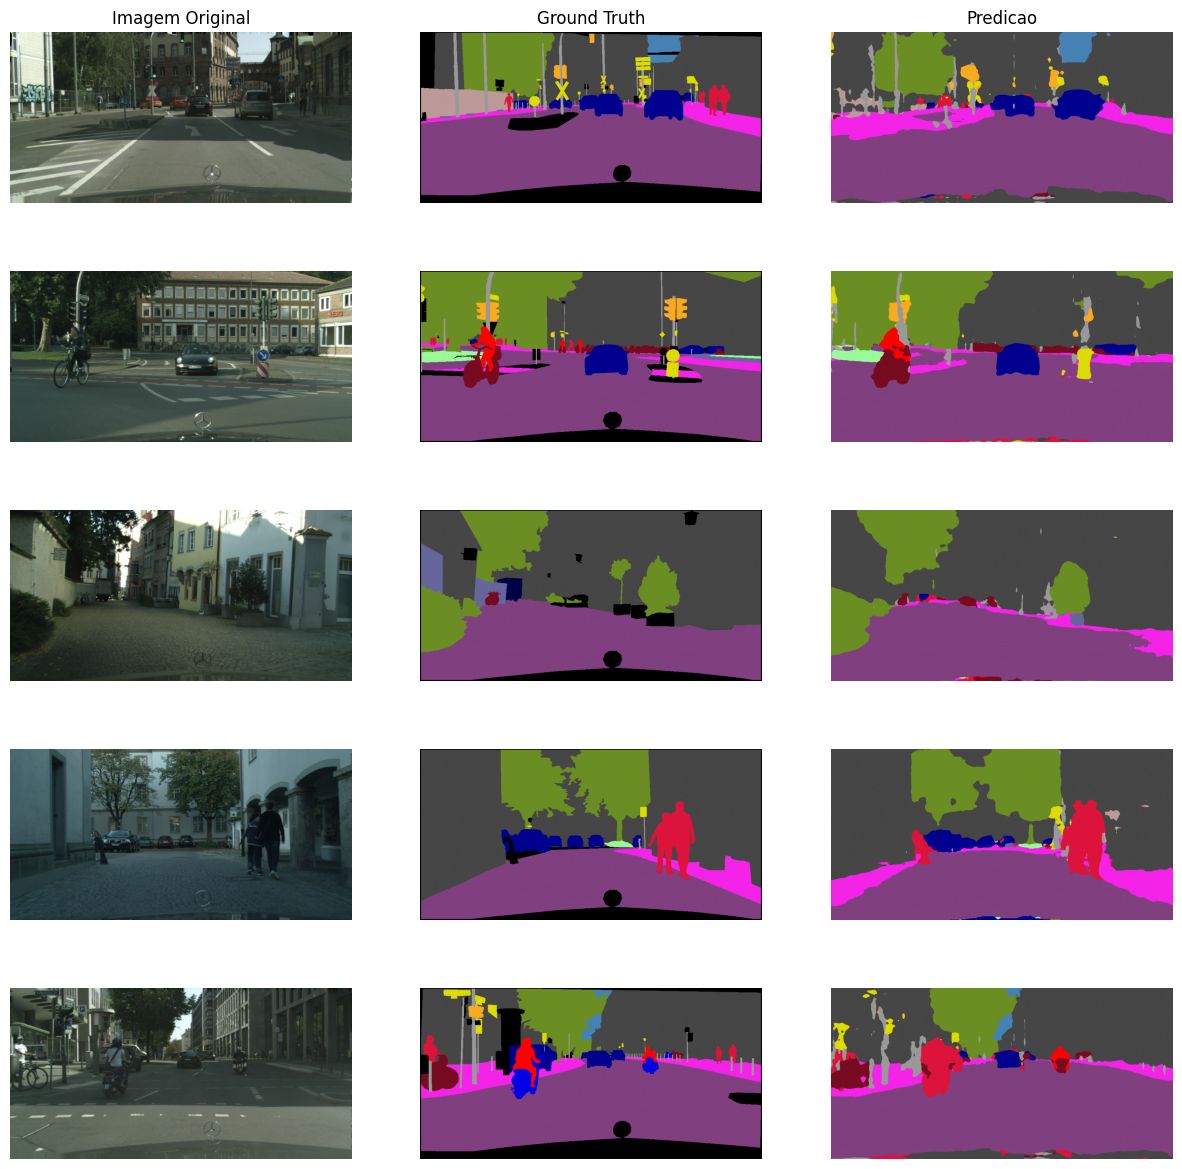

In [ ]:
# Comparando mascaras verdadeirass com as mascaras preditas pelo modelo
dataset_show(val_dataset, n=5, predict_masks=True, model=loaded_model, device=device, cmap=cmap)

In [ ]:
torch.cuda.empty_cache()